# Conditional Face Generation with a CVAE

This notebook contains the experiments, visualizations, and analysis used to evaluate the Conditional Variational Autoencoder (CVAE) trained on the CelebA dataset.

## Project goals

The main objective is to investigate whether a CVAE can:

- Generate realistic face images conditioned on facial attributes.
- Reconstruct input images while preserving important facial features.
- Modify selected attributes (e.g. gender, eyeglasses, hair color) while maintaining the identity of the person.

## Experiments

The notebook includes the following experiments:

1. Random face generation from user-defined attributes.
2. Reconstruction quality evaluation on CelebA samples.
3. Attribute interpolation (e.g. Male → Female, No Glasses → Glasses).
4. Direct attribute editing of existing face images.

In [90]:
import torch
from src.model import CVAE
from src.dataset import CelebADataset

CELEBA_ATTRIBUTES = [
"5_o_Clock_Shadow",
"Arched_Eyebrows",
"Attractive",
"Bags_Under_Eyes",
"Bald",
"Bangs",
"Big_Lips",
"Big_Nose",
"Black_Hair",
"Blond_Hair",
"Blurry",
"Brown_Hair",
"Bushy_Eyebrows",
"Chubby",
"Double_Chin",
"Eyeglasses",
"Goatee",
"Gray_Hair",
"Heavy_Makeup",
"High_Cheekbones",
"Male",
"Mouth_Slightly_Open",
"Mustache",
"Narrow_Eyes",
"No_Beard",
"Oval_Face",
"Pale_Skin",
"Pointy_Nose",
"Receding_Hairline",
"Rosy_Cheeks",
"Sideburns",
"Smiling",
"Straight_Hair",
"Wavy_Hair",
"Wearing_Earrings",
"Wearing_Hat",
"Wearing_Lipstick",
"Wearing_Necklace",
"Wearing_Necktie",
"Young"
]


SELECTED_ATTRIBUTES = CELEBA_ATTRIBUTES

model_path = "experiments/cvae_z512_beta0.1_lr0.001_bs128_epochs20_trainLenall_attrs40/model.pth"
latent_dim = 512

test_dataset = CelebADataset(split="test", SELECTED_ATTRIBUTES=SELECTED_ATTRIBUTES, image_size=64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(latent_dim=latent_dim, n_classes=len(SELECTED_ATTRIBUTES), image_size=64)
model.load_state_dict(torch.load(model_path))
model.to(device)

CVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=4136, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu): Linear(in_features=1024, out_features=512, bias=True)
  (fc_logvar): Linear(in_features=102

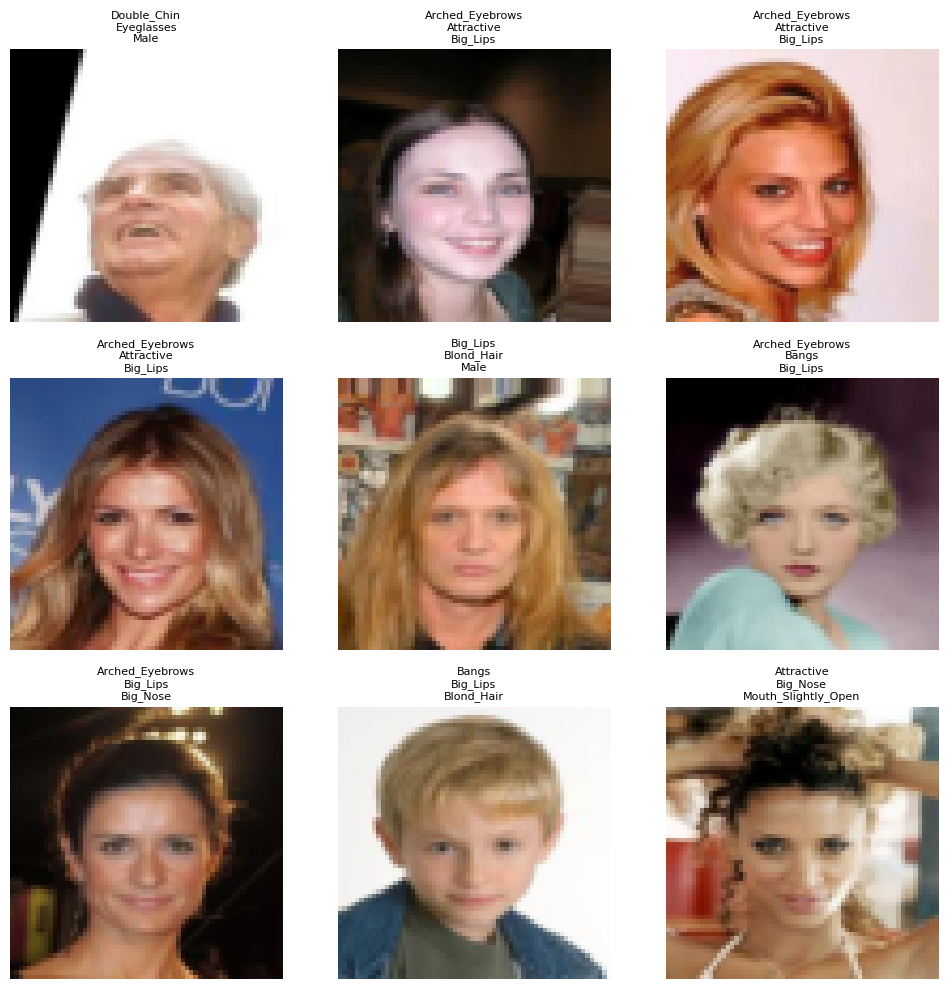

In [109]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

loader = DataLoader(
    test_dataset,
    batch_size=9,
    shuffle=True
)

images, attrs, _ = next(iter(loader))

images = (images + 1) / 2
images = images.clamp(0, 1)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):

    ax.imshow(images[i].permute(1, 2, 0))

    active_attrs = [
        SELECTED_ATTRIBUTES[j]
        for j in range(len(SELECTED_ATTRIBUTES))
        if attrs[i][j] > 0
    ]

    ax.set_title(
        "\n".join(active_attrs[:3]),
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [114]:
train_dataset = CelebADataset(split="train", SELECTED_ATTRIBUTES=SELECTED_ATTRIBUTES, image_size=64)
counts = ((train_dataset.attributes.loc[train_dataset.images] + 1) // 2).sum()

n = len(train_dataset.images)

print(f"Dataset size: {n}\n")

for attr, count in counts.items():
    pct = 100 * count / n

    print(
        f"{attr:<25}"
        f"{int(count):>8}"
        f" ({pct:5.1f}%)"
    )

Dataset size: 162770

5_o_Clock_Shadow            18177 ( 11.2%)
Arched_Eyebrows             43278 ( 26.6%)
Attractive                  83603 ( 51.4%)
Bags_Under_Eyes             33280 ( 20.4%)
Bald                         3713 (  2.3%)
Bangs                       24685 ( 15.2%)
Big_Lips                    39213 ( 24.1%)
Big_Nose                    38341 ( 23.6%)
Black_Hair                  38906 ( 23.9%)
Blond_Hair                  24267 ( 14.9%)
Blurry                       8362 (  5.1%)
Brown_Hair                  33192 ( 20.4%)
Bushy_Eyebrows              23386 ( 14.4%)
Chubby                       9389 (  5.8%)
Double_Chin                  7571 (  4.7%)
Eyeglasses                  10521 (  6.5%)
Goatee                      10337 (  6.4%)
Gray_Hair                    6896 (  4.2%)
Heavy_Makeup                62555 ( 38.4%)
High_Cheekbones             73645 ( 45.2%)
Male                        68261 ( 41.9%)
Mouth_Slightly_Open         78486 ( 48.2%)
Mustache                     664

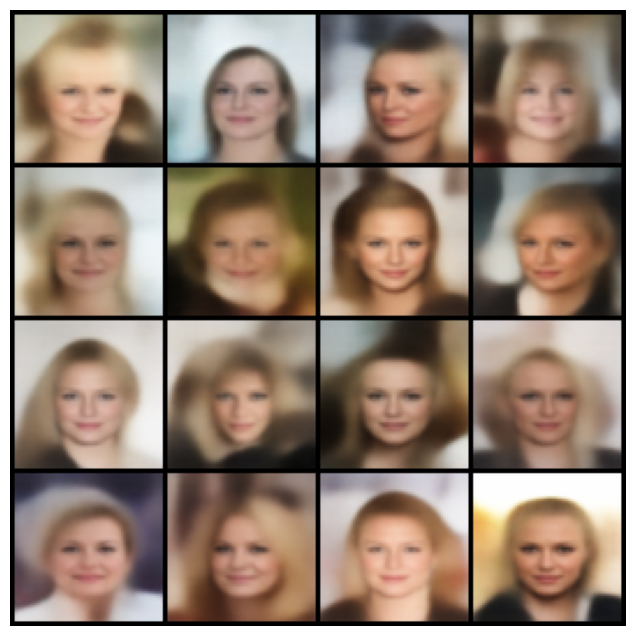

In [107]:
from src.utils import show_generated_faces

attrs = {
    "5_o_Clock_Shadow": 0,
    "Arched_Eyebrows": 0,
    "Attractive": 1,
    "Bags_Under_Eyes": 0,
    "Bald": 0,
    "Bangs": 0,
    "Big_Lips": 0,
    "Big_Nose": 0,
    "Black_Hair": 0,
    "Blond_Hair": 1,
    "Blurry": -2,
    "Brown_Hair": 0,
    "Bushy_Eyebrows": 0,
    "Chubby": 0,
    "Double_Chin": 0,
    "Eyeglasses": 0,
    "Goatee": 0,
    "Gray_Hair": 0,
    "Heavy_Makeup": 0,
    "High_Cheekbones": 0,
    "Male": -1,
    "Mouth_Slightly_Open": 0,
    "Mustache": 0,
    "Narrow_Eyes": 0,
    "No_Beard": 0,
    "Oval_Face": 0,
    "Pale_Skin": 0,
    "Pointy_Nose": 0,
    "Receding_Hairline": 0,
    "Rosy_Cheeks": 1,
    "Sideburns": 0,
    "Smiling": 1,
    "Straight_Hair": 0,
    "Wavy_Hair": 0,
    "Wearing_Earrings": 0,
    "Wearing_Hat": 0,
    "Wearing_Lipstick": 0,
    "Wearing_Necklace": 0,
    "Wearing_Necktie": 0,
    "Young": 0
}


show_generated_faces(
    model=model,
    selected_attrs=attrs,
    attribute_names=SELECTED_ATTRIBUTES,
    latent_dim=latent_dim,
    n_samples=16,
    device=device
)   

MSE: 0.031708
MAE: 0.117160


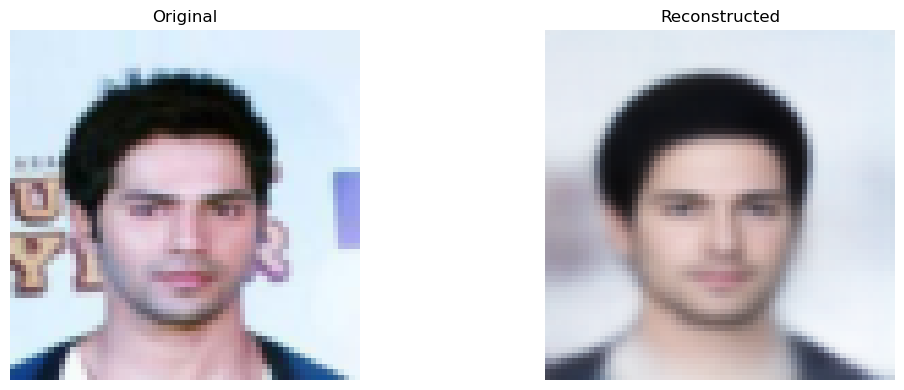

{'mse': 0.03170802444219589,
 'mae': 0.1171598732471466,
 'mu': tensor([[-2.0009e-01,  3.7545e-02,  1.4434e-01,  1.1444e-01,  1.9290e-01,
          -6.6441e-02, -1.9310e-01,  1.1263e-01,  1.0659e-02, -6.2086e-02,
           8.9246e-03,  8.1047e-02, -9.6177e-02, -7.7393e-02, -5.2742e-02,
           7.7034e-02,  2.2757e-01, -9.3551e-02, -1.0048e-01, -6.9751e-02,
           4.8696e-01, -5.2563e-02, -2.5511e-01,  3.5973e-02, -2.2967e-01,
          -1.6037e-01, -3.5425e-02,  4.7192e-02, -3.8878e-02, -2.8030e-03,
           1.5412e+00, -1.6141e-01,  2.3189e-01,  9.5138e-02,  4.1597e-02,
           2.5593e-01,  2.5351e-02,  1.7112e-02,  1.7618e-02,  5.0417e-02,
           1.0396e-01,  1.4829e-01,  8.5135e-03, -2.0052e-01,  3.6831e-02,
          -2.0060e-01, -1.9252e-01,  1.7118e-01,  1.9674e-02,  9.0718e-02,
          -5.0184e-02, -2.3038e-01, -2.5339e-01, -2.1928e-02, -3.2129e-01,
          -2.0283e-01, -5.5104e-02,  3.3471e-01,  1.4627e-01,  7.6527e-02,
           6.5943e-02, -6.5635e-02,  

In [92]:
from src.utils import analyze_reconstruction, show_tensor_image
from torch.utils.data import DataLoader

test_loader =  DataLoader(test_dataset, batch_size=128, shuffle=False)
imgs, _, _ = next(iter(test_loader))
example_img = imgs[5]


analyze_reconstruction(
    model,
    example_img,
    {"Male": 1,
     "Black_Hair": 1,
     "Bushy_Eyebrows": 1,
     "Mustache": 0.5,
     },
    SELECTED_ATTRIBUTES,
    device=device
)

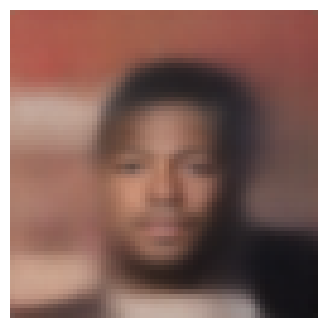

In [130]:
from src.utils import show_from_latent

z = torch.randn(1, latent_dim).to(device)
male = {
    "Male": 1,
    "Black_Hair": 1,
    "Blury": -1
}
show_from_latent(
    model,
    z,
    male,
    SELECTED_ATTRIBUTES,
    device
)

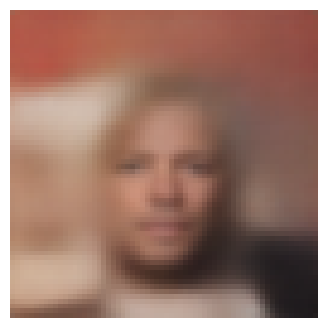

In [ ]:
changes = {
    "Male": 1,
    "Black_Hair": 0,
    "Blond_Hair": 1,
    "Blury": -1,
}
show_from_latent(
    model,
    z,
    changes,
    SELECTED_ATTRIBUTES,
    device
)

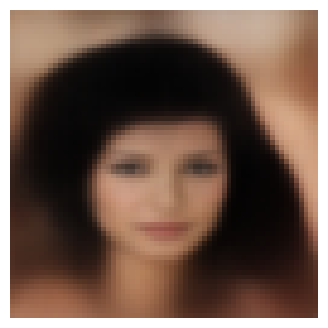

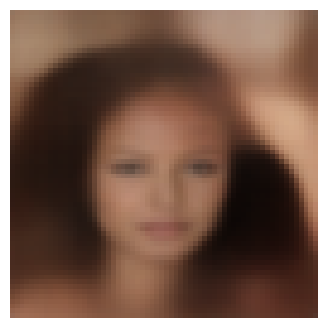

In [148]:
z = torch.randn(1, latent_dim).to(device)

show_from_latent(
    model,
    z,
    {
    "Male": -1,
    "Black_Hair": 1,
    "Bald": -1
    },
    SELECTED_ATTRIBUTES,
    device
)
show_from_latent(
    model,
    z,
    {
    "Male": -1,
    "Black_Hair": 0,
    "Bald": 3
    },
    SELECTED_ATTRIBUTES,
    device
)



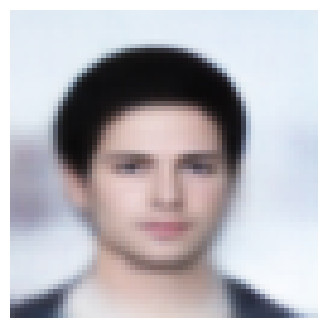

In [95]:
from src.utils import edit_face_attributes,show_tensor_image,load_image

attrs = {
    "5_o_Clock_Shadow": 0,
    "Arched_Eyebrows": 0,
    "Attractive": 0,
    "Bags_Under_Eyes": 0,
    "Bald": 0,
    "Bangs": 0,
    "Big_Lips": 0,
    "Big_Nose": 0,
    "Black_Hair": 0,
    "Blond_Hair": 1,
    "Blurry": 0,
    "Brown_Hair": 0,
    "Bushy_Eyebrows": 1,
    "Chubby": 0,
    "Double_Chin": 0,
    "Eyeglasses": 0,
    "Goatee": 0,
    "Gray_Hair": 0,
    "Heavy_Makeup": 0,
    "High_Cheekbones": 0,
    "Male": 1,
    "Mouth_Slightly_Open": 0,
    "Mustache": 0,
    "Narrow_Eyes": 0,
    "No_Beard": 0,
    "Oval_Face": 0,
    "Pale_Skin": 0,
    "Pointy_Nose": 0,
    "Receding_Hairline": 0,
    "Rosy_Cheeks": 0,
    "Sideburns": 0,
    "Smiling": -1,
    "Straight_Hair": 0,
    "Wavy_Hair": 0,
    "Wearing_Earrings": 0,
    "Wearing_Hat": 0,
    "Wearing_Lipstick": 0,
    "Wearing_Necklace": 0,
    "Wearing_Necktie": 0,
    "Young": 0
}


edited_image = edit_face_attributes(
    model,
    example_img.unsqueeze(0),
    attrs,

    SELECTED_ATTRIBUTES,
    device
)

show_tensor_image(edited_image)

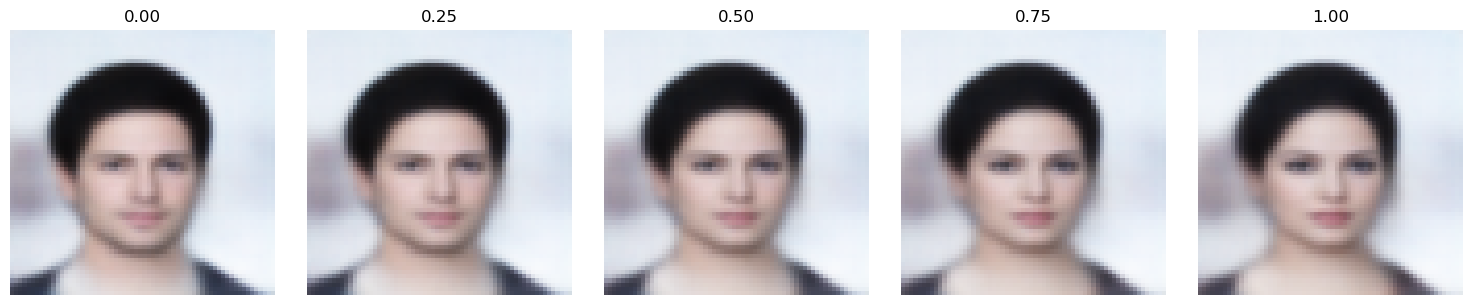

In [96]:
from src.utils import show_attribute_transition


show_attribute_transition(
    model,
    image=example_img,

    start_attrs={
        "Male": 1,
    },

    end_attrs={
        "Male": -1,
    },

    attribute_names=SELECTED_ATTRIBUTES,
    steps=5,
    device=device
)

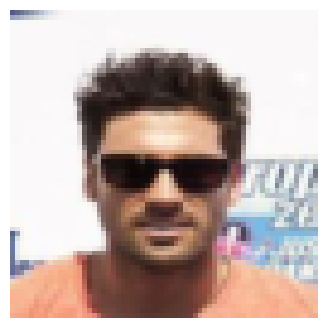

In [97]:
example_img = imgs[9]

show_tensor_image(example_img)

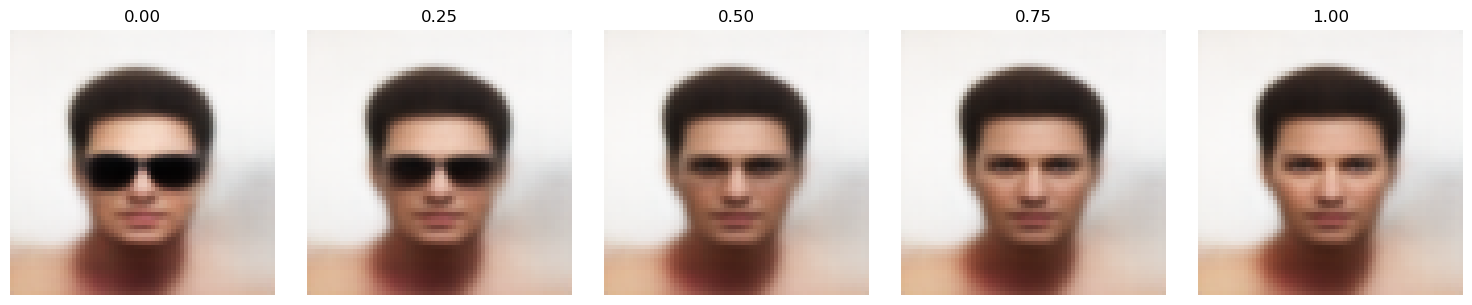

In [99]:
show_attribute_transition(
    model,
    image=example_img,

    start_attrs={
        "Eyeglasses": 2,
        
    },

    end_attrs={
        "Eyeglasses": -1,
    },

    attribute_names=SELECTED_ATTRIBUTES,
    steps=5,
    device=device
)